In [17]:
import os
print(os.getcwd())

C:\Users\HP\Documents\Projekti\Projekat nekretnine


In [18]:
import pandas as pd

df = pd.read_csv("stanovi_beograd.csv")
df.head()

,naslov,cena_eur,lokacija,kvadratura,broj_soba
0,"Lux trosoban stan 75m2, odlicna lokacija",325.000,"Beograd, Opština Palilula, Hadžipopovac",75 m2,3.5
1,Duplex 118 m² kod Đeram pijace,349.000,"Beograd, Opština Zvezdara, Đeram pijaca, Pećska",118 m2,5.0
2,"BLOK 61 u parku kod vrtića, miran, odličan 2,5",230.000,"Beograd, Opština Novi Beograd, Blok 61, Dr Iva...",66 m2,2.5
3,Renoviran i funkcionalan stan u bloku 63,300.000,"Beograd, Opština Novi Beograd, Blok 63, Gandijeva",73 m2,3.0
4,Jajinci Zelena Oaza premijum stan 4.0,205.000,"Beograd, Opština Voždovac, Jajinci, Ilije Petr...",97 m2,4.0


In [19]:
print(f"Broj redova: {len(df)}")
print(f"Broj kolona: {len(df.columns)}")
df.info()

Broj redova: 800
Broj kolona: 5
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   naslov      800 non-null    str  
 1   cena_eur    800 non-null    str  
 2   lokacija    800 non-null    str  
 3   kvadratura  800 non-null    str  
 4   broj_soba   800 non-null    str  
dtypes: str(5)
memory usage: 31.4 KB


In [20]:
# CENA: uklanjamo tacke (separator hiljada) pa pretvaramo u ceo broj
df["cena_eur"] = df["cena_eur"].str.replace(".", "", regex=False).astype(int)

# KVADRATURA: izvlacimo samo cifre (i eventualnu decimalu), bez obzira sta je oko njih
df["kvadratura"] = df["kvadratura"].str.extract(r"(\d+[.,]?\d*)")[0].str.replace(",", ".").astype(float)

# BROJ SOBA: izvlacimo broj, "5+" tretiramo kao 5
df["broj_soba"] = df["broj_soba"].str.extract(r"(\d+[.,]?\d*)")[0].str.replace(",", ".").astype(float)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   naslov      800 non-null    str    
 1   cena_eur    800 non-null    int64  
 2   lokacija    800 non-null    str    
 3   kvadratura  800 non-null    float64
 4   broj_soba   800 non-null    float64
dtypes: float64(2), int64(1), str(2)
memory usage: 31.4 KB


,naslov,cena_eur,lokacija,kvadratura,broj_soba
0,"Lux trosoban stan 75m2, odlicna lokacija",325000,"Beograd, Opština Palilula, Hadžipopovac",75.0,3.5
1,Duplex 118 m² kod Đeram pijace,349000,"Beograd, Opština Zvezdara, Đeram pijaca, Pećska",118.0,5.0
2,"BLOK 61 u parku kod vrtića, miran, odličan 2,5",230000,"Beograd, Opština Novi Beograd, Blok 61, Dr Iva...",66.0,2.5
3,Renoviran i funkcionalan stan u bloku 63,300000,"Beograd, Opština Novi Beograd, Blok 63, Gandijeva",73.0,3.0
4,Jajinci Zelena Oaza premijum stan 4.0,205000,"Beograd, Opština Voždovac, Jajinci, Ilije Petr...",97.0,4.0


In [21]:
df[["cena_eur", "kvadratura", "broj_soba"]].describe()

,cena_eur,kvadratura,broj_soba
count,8.000000e+02,800.000000,800.000000
mean,2.819051e+05,73.672425,2.663125
std,2.232167e+05,37.127537,1.021032
min,5.700000e+04,15.000000,0.500000
25%,1.490000e+05,49.000000,2.000000
50%,2.200000e+05,65.000000,2.500000
75%,3.290000e+05,87.000000,3.000000
max,2.000000e+06,316.000000,5.000000


In [22]:
print(f"Broj duplikata (po naslovu): {df.duplicated(subset=['naslov']).sum()}")

Broj duplikata (po naslovu): 13


In [23]:
df = df.drop_duplicates(subset=["naslov"])
print(f"Broj redova nakon uklanjanja duplikata: {len(df)}")

Broj redova nakon uklanjanja duplikata: 787


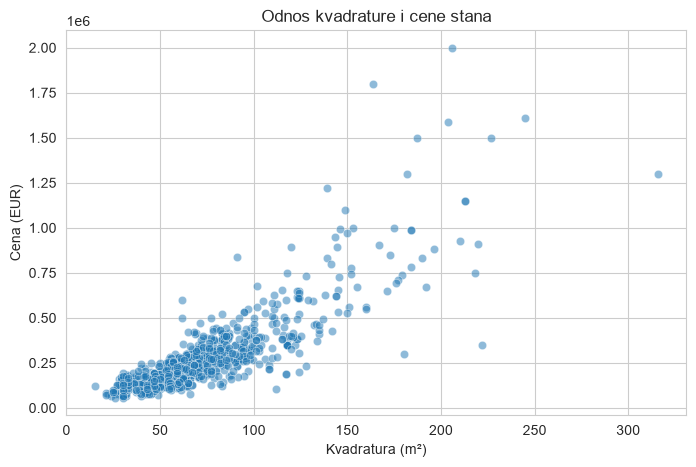

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Podesavanje velicine i stila grafikona
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))

# Odnos kvadrature i cene - ocekujemo da vece kvadrature imaju vece cene
sns.scatterplot(data=df, x="kvadratura", y="cena_eur", alpha=0.5)
plt.title("Odnos kvadrature i cene stana")
plt.xlabel("Kvadratura (m²)")
plt.ylabel("Cena (EUR)")
plt.show()

In [25]:
# Prikazujemo stanove sa najvecom cenom po m2 - cesto otkrije greske ili prave "luksuze"
df["cena_po_m2"] = df["cena_eur"] / df["kvadratura"]
df.sort_values("cena_po_m2", ascending=False).head(10)[["naslov", "cena_eur", "kvadratura", "cena_po_m2"]]

,naslov,cena_eur,kvadratura,cena_po_m2
520,Četvorosoban | St. Regis | Pogled na reku,1800000,163.50,11009.174312
515,Dvosoban| BW St. Regis | Pogled na reku,599000,61.65,9716.139497
132,Premium penthouse 206m2 sa krovnom terasom 180m2,2000000,206.00,9708.737864
526,Trosoban | BW St. Regis | Poged na reku,838400,91.13,9200.043893
793,Četvorosoban | BW Terraces | Pogled na reku | Lux,1220000,139.37,8753.677262
563,BW Kula | Ekskluzivan luksuzni stan sa pogledom,500000,61.65,8110.300081
589,Funkcionalan Studio na Dorćolu,120000,15.00,8000.000000
151,"Bw Riviera, PrestiŽ Na 24. Spratu",1498000,187.25,8000.000000
411,"BW Riviera, najpoželjniji stan, direktno na re...",1590000,204.00,7794.117647
573,BW Riviera-Sava Promenada-fantastična prilika!...,895000,119.87,7466.421957


In [26]:
df[["cena_eur", "kvadratura", "broj_soba"]].corr()

,cena_eur,kvadratura,broj_soba
cena_eur,1.000000,0.843787,0.584967
kvadratura,0.843787,1.000000,0.802719
broj_soba,0.584967,0.802719,1.000000


In [27]:
df.to_csv("stanovi_beograd_ocisceno.csv", index=False, encoding="utf-8-sig")
print("Sacuvano!")

Sacuvano!


In [1]:
import pandas as pd

df = pd.read_csv("stanovi_beograd_ocisceno.csv")

# X = ULAZI (ono sto model gleda da bi predvideo)
# y = IZLAZ (ono sto pokusavamo da predvidimo - cena)
X = df[["kvadratura", "broj_soba"]]
y = df["cena_eur"]

print(f"Broj primera: {len(X)}")
print(X.head())
print(y.head())

Broj primera: 787
   kvadratura  broj_soba
0        75.0        3.5
1       118.0        5.0
2        66.0        2.5
3        73.0        3.0
4        97.0        4.0
0    325000
1    349000
2    230000
3    300000
4    205000
Name: cena_eur, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Trening skup: {len(X_train)} stanova")
print(f"Test skup: {len(X_test)} stanova")

Trening skup: 629 stanova
Test skup: 158 stanova


In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model je istreniran!")

Model je istreniran!


In [5]:
from sklearn.metrics import mean_absolute_error, r2_score

# Model predvidja cene za test skup (koji nije video tokom treniranja)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Prosecna greska (MAE): {mae:,.0f} EUR")
print(f"R² skor: {r2:.3f}")

Prosecna greska (MAE): 67,583 EUR
R² skor: 0.732


In [6]:
# Izmisljeni stan - promeni brojeve kako zelis da eksperimentises
novi_stan = pd.DataFrame({
    "kvadratura": [65],
    "broj_soba": [2.5]
})

predvidjena_cena = model.predict(novi_stan)[0]
print(f"Predvidjena cena za stan od {novi_stan['kvadratura'][0]}m2, {novi_stan['broj_soba'][0]} soba:")
print(f"{predvidjena_cena:,.0f} EUR")

Predvidjena cena za stan od 65m2, 2.5 soba:
237,569 EUR


In [7]:
# Izmisljeni stan - promeni brojeve kako zelis da eksperimentises
novi_stan = pd.DataFrame({
    "kvadratura": [38],
    "broj_soba": [1]
})

predvidjena_cena = model.predict(novi_stan)[0]
print(f"Predvidjena cena za stan od {novi_stan['kvadratura'][0]}m2, {novi_stan['broj_soba'][0]} soba:")
print(f"{predvidjena_cena:,.0f} EUR")

Predvidjena cena za stan od 38m2, 1 soba:
163,168 EUR


In [8]:
# Izvlacimo opstinu - drugi deo teksta, razdvojen zarezima
df["opstina"] = df["lokacija"].str.split(",").str[1].str.strip()

print(f"Broj razlicitih opstina: {df['opstina'].nunique()}")
df["opstina"].value_counts()

Broj razlicitih opstina: 14


opstina
Opština Novi Beograd    128
Opština Zvezdara        108
Opština Voždovac         94
Opština Savski venac     83
Opština Vračar           78
Opština Zemun            76
Opština Palilula         65
Opština Stari grad       55
Opština Čukarica         39
Opština Rakovica         38
Opština Grocka           10
Opština Surčin           10
Opština Mladenovac        2
Opština Barajevo          1
Name: count, dtype: int64

In [9]:
# One-hot encoding - svaka opstina postaje svoja kolona (0 ili 1)
opstina_dummies = pd.get_dummies(df["opstina"], prefix="opstina")

print(f"Broj novih kolona: {opstina_dummies.shape[1]}")
opstina_dummies.head()

Broj novih kolona: 14


,opstina_Opština Barajevo,opstina_Opština Grocka,opstina_Opština Mladenovac,opstina_Opština Novi Beograd,opstina_Opština Palilula,opstina_Opština Rakovica,opstina_Opština Savski venac,opstina_Opština Stari grad,opstina_Opština Surčin,opstina_Opština Voždovac,opstina_Opština Vračar,opstina_Opština Zemun,opstina_Opština Zvezdara,opstina_Opština Čukarica
0,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [10]:
print(opstina_dummies.head())

   opstina_Opština Barajevo  opstina_Opština Grocka  \
0                     False                   False   
1                     False                   False   
2                     False                   False   
3                     False                   False   
4                     False                   False   

   opstina_Opština Mladenovac  opstina_Opština Novi Beograd  \
0                       False                         False   
1                       False                         False   
2                       False                          True   
3                       False                          True   
4                       False                         False   

   opstina_Opština Palilula  opstina_Opština Rakovica  \
0                      True                     False   
1                     False                     False   
2                     False                     False   
3                     False                     False   
4    

In [11]:
# Spajamo kvadraturu, broj soba, i sve opstinske kolone u jedan X
X = pd.concat([df[["kvadratura", "broj_soba"]], opstina_dummies], axis=1)
y = df["cena_eur"]

print(f"Broj kolona u X sad: {X.shape[1]}")
X.head()

Broj kolona u X sad: 16


,kvadratura,broj_soba,opstina_Opština Barajevo,opstina_Opština Grocka,opstina_Opština Mladenovac,opstina_Opština Novi Beograd,opstina_Opština Palilula,opstina_Opština Rakovica,opstina_Opština Savski venac,opstina_Opština Stari grad,opstina_Opština Surčin,opstina_Opština Voždovac,opstina_Opština Vračar,opstina_Opština Zemun,opstina_Opština Zvezdara,opstina_Opština Čukarica
0,75.0,3.5,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,118.0,5.0,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,66.0,2.5,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,73.0,3.0,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,97.0,4.0,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Prosecna greska (MAE): {mae:,.0f} EUR")
print(f"R² skor: {r2:.3f}")

Prosecna greska (MAE): 62,331 EUR
R² skor: 0.757


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Prosecna greska (MAE): {mae_rf:,.0f} EUR")
print(f"Random Forest - R² skor: {r2_rf:.3f}")

print(f"\nPoredjenje:")
print(f"Linear Regression - MAE: {mae:,.0f} EUR, R²: {r2:.3f}")
print(f"Random Forest      - MAE: {mae_rf:,.0f} EUR, R²: {r2_rf:.3f}")

Random Forest - Prosecna greska (MAE): 59,098 EUR
Random Forest - R² skor: 0.596

Poredjenje:
Linear Regression - MAE: 62,331 EUR, R²: 0.757
Random Forest      - MAE: 59,098 EUR, R²: 0.596


In [16]:
# Pravimo tabelu poredjenja stvarne i predvidjene cene za test skup
rezultati = X_test.copy()
rezultati["stvarna_cena"] = y_test
rezultati["predvidjena_cena"] = y_pred_rf
rezultati["greska"] = abs(rezultati["stvarna_cena"] - rezultati["predvidjena_cena"])

# 10 najgorih predvidjanja
rezultati.sort_values("greska", ascending=False).head(10)[
    ["kvadratura", "broj_soba", "stvarna_cena", "predvidjena_cena", "greska"]
]

,kvadratura,broj_soba,stvarna_cena,predvidjena_cena,greska
548,218.00,3.0,749000,1.618005e+06,869005.000000
335,210.00,4.0,929000,1.704285e+06,775285.000000
334,149.00,5.0,1100000,6.015436e+05,498456.400000
231,175.00,5.0,999900,6.690806e+05,330819.450000
682,137.00,4.5,493200,7.686475e+05,275447.483333
77,190.00,4.0,830000,1.092520e+06,262520.000000
424,117.00,3.0,190000,4.085360e+05,218536.010000
247,117.00,3.0,190000,4.085360e+05,218536.010000
650,70.00,2.0,226000,4.077740e+05,181774.000000
519,151.87,4.0,745000,9.119275e+05,166927.500000


In [17]:
print(rezultati.sort_values("greska", ascending=False).head(10)[
    ["kvadratura", "broj_soba", "stvarna_cena", "predvidjena_cena", "greska"]
])

     kvadratura  broj_soba  stvarna_cena  predvidjena_cena         greska
548      218.00        3.0        749000      1.618005e+06  869005.000000
335      210.00        4.0        929000      1.704285e+06  775285.000000
334      149.00        5.0       1100000      6.015436e+05  498456.400000
231      175.00        5.0        999900      6.690806e+05  330819.450000
682      137.00        4.5        493200      7.686475e+05  275447.483333
77       190.00        4.0        830000      1.092520e+06  262520.000000
424      117.00        3.0        190000      4.085360e+05  218536.010000
247      117.00        3.0        190000      4.085360e+05  218536.010000
650       70.00        2.0        226000      4.077740e+05  181774.000000
519      151.87        4.0        745000      9.119275e+05  166927.500000


In [18]:
df.loc[[424, 247]]

,naslov,cena_eur,lokacija,kvadratura,broj_soba,cena_po_m2,opstina
424,"Moderan duplex, odlična lokacija, Miljakovac 1",190000,"Beograd, Opština Rakovica, Miljakovac, Dimitri...",117.0,3.0,1623.931624,Opština Rakovica
247,"Sređen, dupleks, savršena lokacija, Miljakovac",190000,"Beograd, Opština Rakovica, Miljakovac, Dimitri...",117.0,3.0,1623.931624,Opština Rakovica


In [19]:
df.loc[[424, 247]]

,naslov,cena_eur,lokacija,kvadratura,broj_soba,cena_po_m2,opstina
424,"Moderan duplex, odlična lokacija, Miljakovac 1",190000,"Beograd, Opština Rakovica, Miljakovac, Dimitri...",117.0,3.0,1623.931624,Opština Rakovica
247,"Sređen, dupleks, savršena lokacija, Miljakovac",190000,"Beograd, Opština Rakovica, Miljakovac, Dimitri...",117.0,3.0,1623.931624,Opština Rakovica


In [20]:
print(df.loc[[424, 247]])

                                             naslov  cena_eur  \
424  Moderan duplex, odlična lokacija, Miljakovac 1    190000   
247  Sređen, dupleks, savršena lokacija, Miljakovac    190000   

                                              lokacija  kvadratura  broj_soba  \
424  Beograd, Opština Rakovica, Miljakovac, Dimitri...       117.0        3.0   
247  Beograd, Opština Rakovica, Miljakovac, Dimitri...       117.0        3.0   

      cena_po_m2           opstina  
424  1623.931624  Opština Rakovica  
247  1623.931624  Opština Rakovica  


In [21]:
# Duplikat = ista kvadratura + ista cena + ista lokacija (skoro sigurno isti stan)
broj_pravih_duplikata = df.duplicated(subset=["cena_eur", "kvadratura", "lokacija"]).sum()
print(f"Broj 'pravih' duplikata: {broj_pravih_duplikata}")

df = df.drop_duplicates(subset=["cena_eur", "kvadratura", "lokacija"])
print(f"Broj redova nakon ciscenja: {len(df)}")

Broj 'pravih' duplikata: 38
Broj redova nakon ciscenja: 749


In [22]:
# 1. Izvlacimo opstinu ponovo (iz ocisceni df)
df["opstina"] = df["lokacija"].str.split(",").str[1].str.strip()

# 2. One-hot encoding
opstina_dummies = pd.get_dummies(df["opstina"], prefix="opstina")

# 3. Spajamo X i y
X = pd.concat([df[["kvadratura", "broj_soba"]], opstina_dummies], axis=1)
y = df["cena_eur"]

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 6. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Broj redova: {len(df)}")
print(f"\nLinear Regression - MAE: {mae:,.0f} EUR, R²: {r2:.3f}")
print(f"Random Forest      - MAE: {mae_rf:,.0f} EUR, R²: {r2_rf:.3f}")

Broj redova: 749

Linear Regression - MAE: 54,238 EUR, R²: 0.881
Random Forest      - MAE: 56,428 EUR, R²: 0.852


In [23]:
from sklearn.model_selection import cross_val_score

# Cross-validation za Linear Regression
cv_scores_lr = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")

# Cross-validation za Random Forest
cv_scores_rf = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), X, y, cv=5, scoring="r2")

print("Linear Regression:")
print(f"  R² po testovima: {cv_scores_lr.round(3)}")
print(f"  Prosek: {cv_scores_lr.mean():.3f}, Std: {cv_scores_lr.std():.3f}")

print("\nRandom Forest:")
print(f"  R² po testovima: {cv_scores_rf.round(3)}")
print(f"  Prosek: {cv_scores_rf.mean():.3f}, Std: {cv_scores_rf.std():.3f}")

Linear Regression:
  R² po testovima: [0.794 0.848 0.804 0.793 0.639]
  Prosek: 0.776, Std: 0.071

Random Forest:
  R² po testovima: [0.735 0.814 0.762 0.713 0.711]
  Prosek: 0.747, Std: 0.038


In [24]:
# Prebrojimo koliko puta se svaka opstina pojavljuje
broj_po_opstini = df["opstina"].value_counts()
print(broj_po_opstini)

# Opstine sa manje od 15 primera grupisemo u "Ostalo"
retke_opstine = broj_po_opstini[broj_po_opstini < 15].index
df["opstina_grupisano"] = df["opstina"].apply(lambda x: "Ostalo" if x in retke_opstine else x)

print(f"\nBroj kategorija posle grupisanja: {df['opstina_grupisano'].nunique()}")
df["opstina_grupisano"].value_counts()

opstina
Opština Novi Beograd    119
Opština Zvezdara        101
Opština Voždovac         91
Opština Savski venac     80
Opština Vračar           76
Opština Zemun            69
Opština Palilula         62
Opština Stari grad       54
Opština Čukarica         38
Opština Rakovica         36
Opština Grocka           10
Opština Surčin           10
Opština Mladenovac        2
Opština Barajevo          1
Name: count, dtype: int64

Broj kategorija posle grupisanja: 11


opstina_grupisano
Opština Novi Beograd    119
Opština Zvezdara        101
Opština Voždovac         91
Opština Savski venac     80
Opština Vračar           76
Opština Zemun            69
Opština Palilula         62
Opština Stari grad       54
Opština Čukarica         38
Opština Rakovica         36
Ostalo                   23
Name: count, dtype: int64

In [25]:
# One-hot encoding sa grupisanom opstinom
opstina_dummies = pd.get_dummies(df["opstina_grupisano"], prefix="opstina")

# Spajamo X i y
X = pd.concat([df[["kvadratura", "broj_soba"]], opstina_dummies], axis=1)
y = df["cena_eur"]

# Cross-validation ponovo
cv_scores_lr = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")
cv_scores_rf = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), X, y, cv=5, scoring="r2")

print("Linear Regression:")
print(f"  R² po testovima: {cv_scores_lr.round(3)}")
print(f"  Prosek: {cv_scores_lr.mean():.3f}, Std: {cv_scores_lr.std():.3f}")

print("\nRandom Forest:")
print(f"  R² po testovima: {cv_scores_rf.round(3)}")
print(f"  Prosek: {cv_scores_rf.mean():.3f}, Std: {cv_scores_rf.std():.3f}")

Linear Regression:
  R² po testovima: [0.794 0.858 0.804 0.792 0.643]
  Prosek: 0.778, Std: 0.072

Random Forest:
  R² po testovima: [0.734 0.822 0.759 0.713 0.712]
  Prosek: 0.748, Std: 0.041


In [26]:
import numpy as np

# Log-transformacija cene (log1p = log(1+x), sigurnije za brojeve blizu 0)
y_log = np.log1p(y)

cv_scores_lr_log = cross_val_score(LinearRegression(), X, y_log, cv=5, scoring="r2")
cv_scores_rf_log = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), X, y_log, cv=5, scoring="r2")

print("Linear Regression (log cena):")
print(f"  R² po testovima: {cv_scores_lr_log.round(3)}")
print(f"  Prosek: {cv_scores_lr_log.mean():.3f}, Std: {cv_scores_lr_log.std():.3f}")

print("\nRandom Forest (log cena):")
print(f"  R² po testovima: {cv_scores_rf_log.round(3)}")
print(f"  Prosek: {cv_scores_rf_log.mean():.3f}, Std: {cv_scores_rf_log.std():.3f}")

Linear Regression (log cena):
  R² po testovima: [0.848 0.863 0.835 0.847 0.694]
  Prosek: 0.817, Std: 0.063

Random Forest (log cena):
  R² po testovima: [0.821 0.804 0.806 0.8   0.78 ]
  Prosek: 0.802, Std: 0.013


In [27]:
# Finalni model - Random Forest sa log-transformisanom cenom
y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train_log)

# Predikcije - VRACAMO iz log-skale nazad u obicne evre pomocu np.expm1 (obrnuto od log1p)
y_pred_log = final_model.predict(X_test)
y_pred_final = np.expm1(y_pred_log)
y_test_final = np.expm1(y_test_log)

mae_final = mean_absolute_error(y_test_final, y_pred_final)
r2_final = r2_score(y_test_final, y_pred_final)

print(f"FINALNI MODEL - MAE: {mae_final:,.0f} EUR, R²: {r2_final:.3f}")

FINALNI MODEL - MAE: 54,634 EUR, R²: 0.847


In [28]:
import joblib

joblib.dump(final_model, "model_cena_stanova.pkl")
joblib.dump(list(X.columns), "kolone_modela.pkl")

print("Finalni model sacuvan!")

Finalni model sacuvan!
